# Part 1 — Data Quality and Core Cross-Mouse Consistency

Loads the preprocessed archive, computes within-mouse response reliability
from the cached trial-level spike counts (both in raw response-vector space
and, separately, in RDM space to match the consistency metric), then
measures per-image cross-mouse representational consistency across all 32
mice using RSA. These quantities are the foundation every later part builds
on.

**Outputs saved for downstream notebooks:**
- `part1_outputs.npz`: consistency (118,), noise_ceiling (32, 118) [within-mouse
  response-vector reliability, Sec 1.2], rdm_reliability (32,) [within-mouse
  RDM-space reliability, Sec 1.3b], mean_sparsity (118,), mean_magnitude (118,)

## Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    rdm_split_half_ceiling,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
)

import json
import gc
from itertools import combinations
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')

# ── Color palette (used consistently across all part-notebooks) ────────────────
colors   = apply_plot_style()
COL_DATA = colors["COL_DATA"]   # default single-series consistency curve
COL_FIT  = colors["COL_FIT"]    # model fits / peak annotations
COL_REF  = colors["COL_REF"]    # reference lines / baselines / all-units curves

In [2]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)
N_IMAGES    = manifest['n_images']
SESSION_IDS = manifest['selected_session_ids_visp']
SEED        = manifest['seed']
rng         = np.random.default_rng(SEED)

print(f'Sessions : {len(SESSION_IDS)}')
print(f'Images   : {N_IMAGES}')
print(f'Bins     : {bin_edges[0]:.0f} to {bin_edges[-1]:.0f} ms '
      f'({len(bin_edges)-1} bins × {manifest["bin_width_ms"]} ms)')

Extracting ..\preprocessed_data.zip → ..\preprocessed_data ...


Extraction complete.
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
Sessions : 32
Images   : 118
Bins     : -75 to 404 ms (479 bins × 1 ms)


## Core utility functions

`window_response` is defined identically in every part-notebook that reads
response tensors. `compute_similarity_matrices` and `per_image_consistency`
implement the RSA pipeline used throughout.

## 1.1 — Response matrices

Load the binned spike-count tensors from `responses.h5` for all 32 VISp
sessions. Reconstruct the fixed 0–250 ms response matrix for each session
using `window_response`. These matrices are the input to Section 1.3.

In [3]:
RESPONSE_WINDOW = (0.0, 250.0)   # ms

all_tensors     = {}   # sid → {'tensor', 'unit_ids', 'image_ids'}
response_matrices_full = []   # (n_images, n_units) per session, for RSA

with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for sid in SESSION_IDS:
        grp = f[f'natural_scenes/VISp/{sid}']
        tensor   = grp['tensor'][:]     # (118, n_units, 95) float32
        unit_ids = grp['unit_ids'][:]
        img_ids  = grp['image_ids'][:]

        all_tensors[sid] = {
            'tensor':   tensor,
            'unit_ids': unit_ids,
            'image_ids': img_ids,
        }
        X = window_response(tensor, *RESPONSE_WINDOW)
        response_matrices_full.append(X)

n_units_per_session = [all_tensors[s]['tensor'].shape[1] for s in SESSION_IDS]
print(f'Sessions loaded : {len(all_tensors)}')
print(f'Units per session (sorted): '
      f'{sorted(n_units_per_session, reverse=True)}')

Sessions loaded : 32
Units per session (sorted): [110, 102, 94, 93, 92, 88, 85, 85, 84, 80, 75, 75, 75, 73, 72, 63, 60, 58, 52, 52, 51, 49, 47, 45, 41, 40, 37, 36, 35, 33, 19, 14]


*Methodological note.* The 0–250 ms window spans the full visual response
epoch. `window_response` sums 5 ms bins from t_lo to t_hi then z-scores
per unit (across images), removing mean firing-rate differences between
units and sessions. All downstream comparisons are in terms of response
profile shape, not absolute firing rate.

## 1.2 — Within-mouse response-vector reliability

Estimate how reproducible each image's population response vector is within
a single mouse across the 50 repeated presentations. Split-half reliability
is Spearman-Brown corrected to estimate full-data (all-trial) reliability.
This is a QC diagnostic on the response data, not a normalizing bound on
cross-mouse consistency: it is computed on raw per-unit response vectors,
whereas consistency is computed on image x image similarity structure
(RDM space) — the two live in different spaces and are not directly
comparable as a ratio. (A properly RDM-scoped reliability estimate is
computed separately in Section 1.3b.)

In [4]:
N_SPLITS = 20

reliability_per_session = []   # (n_splits, n_images) per session

with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for sid in SESSION_IDS:
        grp          = f[f'natural_scenes/VISp/{sid}']
        trial_counts = grp['trial_level_0_250ms'][:]   # (n_trials, n_units)
        frames       = grp['trial_frame'][:]            # (n_trials,)

        image_list = sorted(set(frames.tolist()))
        if len(image_list) != N_IMAGES:
            print(f'  Session {sid}: unexpected image count {len(image_list)}, skipping')
            continue

        reliab = np.full((N_SPLITS, N_IMAGES), np.nan)
        for s in range(N_SPLITS):
            for i, img in enumerate(image_list):
                idx = np.where(frames == img)[0]
                if len(idx) < 4:
                    continue
                perm = rng.permutation(idx)
                half = len(perm) // 2
                a = trial_counts[perm[:half]].mean(0).astype(float)
                b = trial_counts[perm[half:2*half]].mean(0).astype(float)
                if a.std() == 0 or b.std() == 0:
                    continue
                r, _ = spearmanr(a, b)
                reliab[s, i] = r

        mean_r = np.nanmean(reliab, axis=0)
        sb     = 2 * mean_r / (1 + mean_r)   # Spearman-Brown correction
        reliability_per_session.append(sb)

reliability_arr    = np.array(reliability_per_session)   # (32, 118)
unitvec_reliability = reliability_arr.mean(0)              # (118,) mean across sessions

print(f'Within-mouse response-vector reliability — mean : {unitvec_reliability.mean():.3f}')
print(f'                                          range  : [{unitvec_reliability.min():.3f}, {unitvec_reliability.max():.3f}]')

Within-mouse response-vector reliability — mean : 0.978
                                          range  : [0.968, 0.983]


*Methodological note.* The Spearman-Brown formula r_SB = 2r / (1 + r)
corrects upward to estimate full-data reliability rather than half-data.
The near-ceiling mean (~0.978) confirms the analysis is not power-limited
by within-session trial noise — the constraint on cross-mouse consistency
is biological variability across individuals, not measurement noise. This
number should not be read as a percentage bound on consistency (see
Section 1.3b for a reliability estimate computed in the same RDM space as
consistency).

## 1.3 — Per-image cross-mouse consistency

For each image, the per-image consistency score is the mean Spearman rank
correlation across all 496 mouse pairs of their row-wise cosine-similarity
profiles. A cluster bootstrap resampling whole mice (not pairs) provides
95% CIs that respect the non-independence of pairs sharing a common animal.

In [5]:
N_BOOT = 1000

sim_matrices                    = compute_similarity_matrices(response_matrices_full)
consistency, per_pair, pairs    = per_image_consistency(sim_matrices)
ci_lower, ci_upper              = cluster_bootstrap_ci(response_matrices_full,
                                                        n_boot=N_BOOT)

sort_idx     = np.argsort(consistency)[::-1]

print(f'Consistency — mean   : {consistency.mean():.3f}')
print(f'             range   : [{consistency.min():.3f}, {consistency.max():.3f}]')
print(f'Mouse pairs  : {len(pairs)}')

Consistency — mean   : 0.314
             range   : [0.142, 0.588]
Mouse pairs  : 496


*Methodological note.* Cosine similarity captures the angle between
population response vectors, which is a meaningful geometric quantity
independent of overall response magnitude (already removed by z-scoring).
The Spearman rank correlation over 117 similarity values is robust to
outlier images and invariant to monotonic rescaling of the similarity values.
Bootstrap self-pairs (same original mouse resampled twice) are excluded to
prevent spurious self-correlation from inflating bootstrap consistency.

## 1.3b — Within-mouse reliability in RDM space

The Section 1.2 reliability is computed on raw per-unit response vectors,
a different space from the image x image similarity structure (RDM) that
`per_image_consistency` operates on in Section 1.3. To get a reliability
estimate that is actually comparable to consistency, each mouse's trials
are split in half, each half is turned into a response matrix and then a
similarity matrix (via `compute_similarity_matrices`), and the two
resulting per-mouse RDMs are Spearman-correlated exactly as
`per_image_consistency` correlates two different mice's RDMs
(`rdm_split_half_ceiling` in `utils.py`), then Spearman-Brown corrected.
This is repeated over 20 random splits and averaged.

In [6]:
N_SPLITS_RDM = 20

rdm_reliab_splits = np.zeros((N_SPLITS_RDM, len(SESSION_IDS)))

with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for s in range(N_SPLITS_RDM):
        mats_half1, mats_half2 = [], []
        for sid in SESSION_IDS:
            grp          = f[f'natural_scenes/VISp/{sid}']
            trial_counts = grp['trial_level_0_250ms'][:]   # (n_trials, n_units)
            frames       = grp['trial_frame'][:]            # (n_trials,)
            image_list   = sorted(set(frames.tolist()))

            n_units = trial_counts.shape[1]
            X1 = np.zeros((N_IMAGES, n_units), dtype=np.float64)
            X2 = np.zeros((N_IMAGES, n_units), dtype=np.float64)
            for i, img in enumerate(image_list):
                idx  = np.where(frames == img)[0]
                perm = rng.permutation(idx)
                half = len(perm) // 2
                X1[i] = trial_counts[perm[:half]].mean(0)
                X2[i] = trial_counts[perm[half:2*half]].mean(0)

            # z-score per unit across images, matching window_response's convention
            X1 = (X1 - X1.mean(0)) / (X1.std(0) + 1e-8)
            X2 = (X2 - X2.mean(0)) / (X2.std(0) + 1e-8)
            mats_half1.append(X1.astype(np.float32))
            mats_half2.append(X2.astype(np.float32))

        rdm_reliab_splits[s] = rdm_split_half_ceiling(mats_half1, mats_half2)

rdm_reliability = rdm_reliab_splits.mean(0)   # (n_mice,) averaged over splits

print(f'RDM-space within-mouse reliability — mean : {rdm_reliability.mean():.3f}')
print(f'                                   range  : [{rdm_reliability.min():.3f}, {rdm_reliability.max():.3f}]')
print(f'(cf. cross-mouse consistency mean = {consistency.mean():.3f}, '
      f'in the same RDM space)')

RDM-space within-mouse reliability — mean : 0.832
                                   range  : [0.609, 0.929]
(cf. cross-mouse consistency mean = 0.314, in the same RDM space)


## 1.4 — Response sparsity and magnitude per image

Compute the two primary image-level predictors used in Part 2: response
sparsity (fraction of units responding below the per-mouse median |z|)
and mean response magnitude. Computed here since they're derived from the
same response matrices already in memory.

In [7]:
mean_magnitudes  = np.zeros((len(response_matrices_full), N_IMAGES))
mean_sparsities  = np.zeros((len(response_matrices_full), N_IMAGES))

for m, X in enumerate(response_matrices_full):
    mean_magnitudes[m]  = np.abs(X).mean(axis=1)
    thresh              = np.median(np.abs(X))
    mean_sparsities[m]  = (np.abs(X) < thresh).mean(axis=1)

mean_magnitude = mean_magnitudes.mean(0)
mean_sparsity  = mean_sparsities.mean(0)

from scipy.stats import spearmanr
r_sp,  p_sp  = spearmanr(consistency, mean_sparsity)
r_mag, p_mag = spearmanr(consistency, mean_magnitude)
print(f'Consistency vs sparsity  : r = {r_sp:.3f},  p = {p_sp:.2e}')
print(f'Consistency vs magnitude : r = {r_mag:.3f},  p = {p_mag:.2e}')

Consistency vs sparsity  : r = -0.470,  p = 7.84e-08
Consistency vs magnitude : r = 0.276,  p = 2.51e-03


## 1.5 — Image gallery prep

Load the downsampled image templates for use in the gallery figures.
The templates are display copies only; no quantitative analysis uses pixel data.

In [8]:
natural_scenes = np.load(ARCHIVE_DIR / 'image_templates.npy')   # (118, 256, 256) uint8
N_GALLERY = 8
top_ids = sort_idx[:N_GALLERY]
bot_ids = sort_idx[-N_GALLERY:]
print(f'Image templates shape: {natural_scenes.shape}  dtype: {natural_scenes.dtype}')

Image templates shape: (118, 256, 256)  dtype: uint8


## Save Part 1 outputs

Save the quantities needed by Parts 2, 7, and (for comparison) Part 8.

In [9]:
np.savez(
    OUTPUTS_DIR / 'part1_outputs.npz',
    consistency         = consistency,           # (118,)
    ci_lower            = ci_lower,              # (118,)
    ci_upper            = ci_upper,              # (118,)
    noise_ceiling       = reliability_arr,       # (32, 118) — within-mouse response-vector reliability (Sec 1.2)
    rdm_reliability     = rdm_reliability,       # (32,) — within-mouse RDM-space reliability (Sec 1.3b)
    mean_sparsity       = mean_sparsity,         # (118,)
    mean_magnitude      = mean_magnitude,        # (118,)
    sort_idx            = sort_idx,              # (118,) sorted high→low
)
print('Saved: part1_outputs.npz')

Saved: part1_outputs.npz


---
## Figures

**Fig. 1** — Cross-mouse consistency is substantial but well below the noise ceiling.
**S1** — Gallery of high- and low-consistency natural images.


Fig 1A — within-mouse response-vector reliability histogram



--- unitvec_reliability ---
shape=(118,)
[0.975723 0.977179 0.981373 0.981235 0.973664 0.982561 0.980575 0.978345 0.977869 0.979968 0.978953 0.978145 0.978531 0.981115 0.978399 0.978432 0.980065 0.980819 0.981647 0.981366]
...[118 elements total]

--- unitvec_reliability_mean ---
0.9777621774628236

Fig 1B — per-image cross-mouse consistency (sorted high to low)

--- image_rank ---
shape=(118,)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
...[118 elements total]

--- consistency_sorted ---
shape=(118,)
[0.588219 0.582116 0.563645 0.519218 0.517019 0.509412 0.497428 0.491192 0.488789 0.487523 0.484811 0.482925 0.468499 0.467885 0.453349 0.45102  0.447967 0.443052 0.442277 0.43608 ]
...[118 elements total]

--- ci_lower_sorted ---
shape=(118,)
[0.544363 0.530285 0.52192  0.464642 0.432402 0.449381 0.435301 0.414986 0.426461 0.394761 0.365247 0.393707 0.382605 0.410075 0.383844 0.383008 0.389483 0.378887 0.371494 0.344055]
...[118 elements total]

--- ci_upper_sorted --

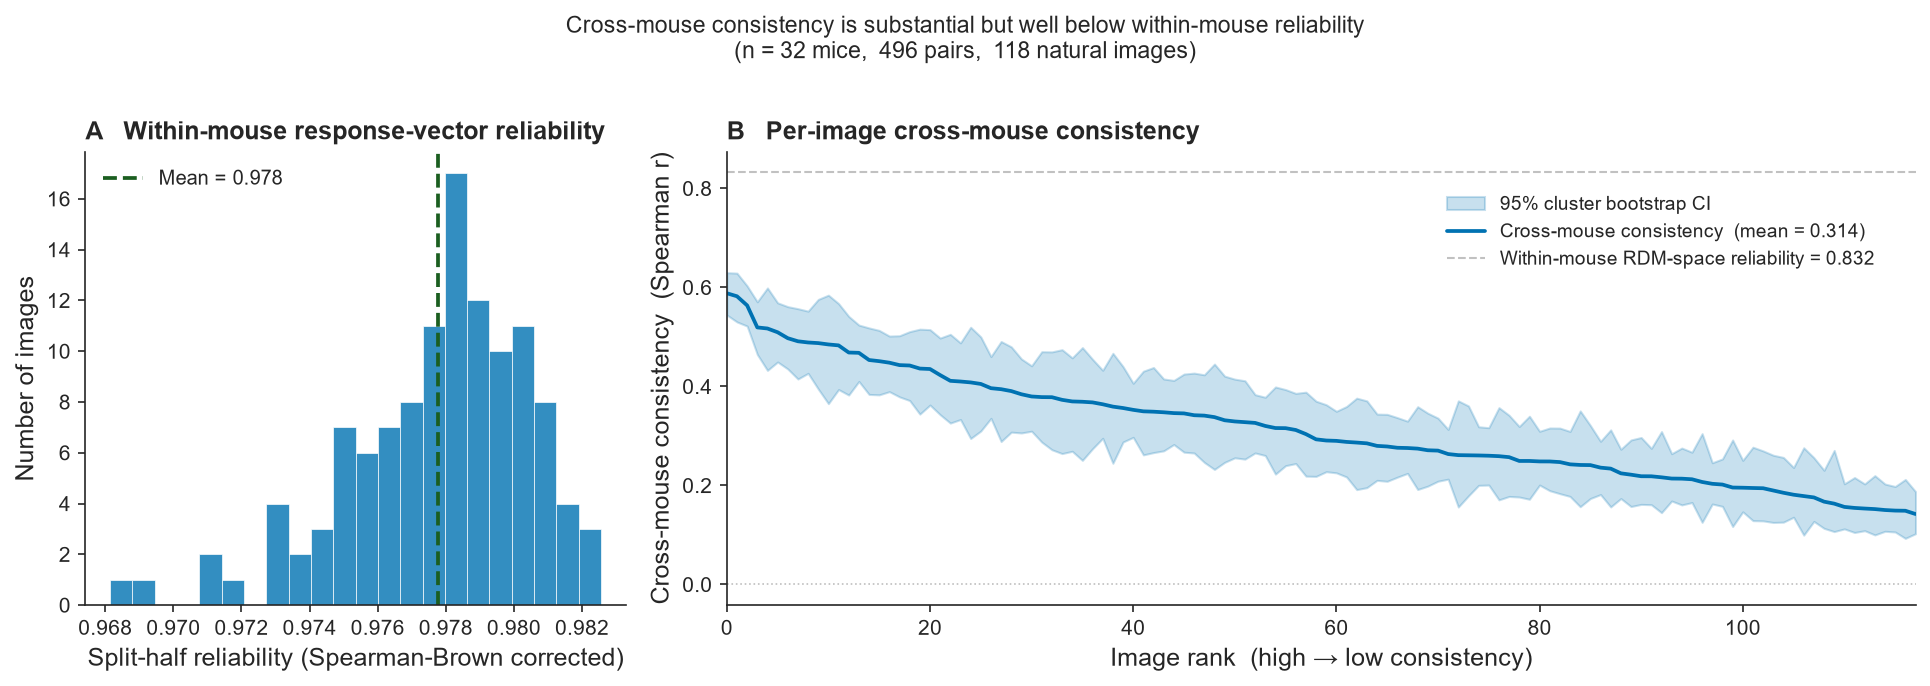

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5),
                         gridspec_kw={'width_ratios': [1, 2.2]})

# ── Panel A: within-mouse reliability histogram ───────────────────────────────
ax = axes[0]
nc_scalar = unitvec_reliability.mean()
ax.hist(unitvec_reliability, bins=22, color=COL_DATA, alpha=0.8,
        edgecolor='white', linewidth=0.4)
ax.axvline(nc_scalar, color=COL_FIT, linestyle='--', linewidth=1.8,
           label=f'Mean = {nc_scalar:.3f}')
ax.set_xlabel('Split-half reliability (Spearman-Brown corrected)')
ax.set_ylabel('Number of images')
ax.set_title('A   Within-mouse response-vector reliability', loc='left',
              fontweight='bold', pad=6)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: sorted consistency curve ─────────────────────────────────────────
ax = axes[1]
x = np.arange(N_IMAGES)
ax.fill_between(x, ci_lower[sort_idx], ci_upper[sort_idx],
                alpha=0.22, color=COL_DATA, label='95% cluster bootstrap CI')
ax.plot(x, consistency[sort_idx], color=COL_DATA, linewidth=1.8,
        label=f'Cross-mouse consistency  (mean = {consistency.mean():.3f})')
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.axhline(rdm_reliability.mean(), color=COL_REF, linestyle='--', linewidth=1,
           alpha=0.6,
           label=f'Within-mouse RDM-space reliability = {rdm_reliability.mean():.3f}')
ax.set_xlabel('Image rank  (high → low consistency)')
ax.set_ylabel('Cross-mouse consistency  (Spearman r)')
ax.set_title('B   Per-image cross-mouse consistency', loc='left', fontweight='bold', pad=6)
ax.set_xlim(0, N_IMAGES - 1)
ax.legend(frameon=False, fontsize=9, loc='upper right', bbox_to_anchor=(0.98, 0.94))
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Cross-mouse consistency is substantial but well below within-mouse reliability\n'
             f'(n = {len(SESSION_IDS)} mice,  {len(pairs)} pairs,  {N_IMAGES} natural images)',
             fontsize=11, y=1.01)

print_figure_data(
    'Fig 1A — within-mouse response-vector reliability histogram',
    unitvec_reliability=unitvec_reliability,
    unitvec_reliability_mean=nc_scalar,
)
print_figure_data(
    'Fig 1B — per-image cross-mouse consistency (sorted high to low)',
    image_rank=x,
    consistency_sorted=consistency[sort_idx],
    ci_lower_sorted=ci_lower[sort_idx],
    ci_upper_sorted=ci_upper[sort_idx],
    rdm_reliability_mean=rdm_reliability.mean(),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_consistency_overview.png', bbox_inches='tight')
plt.show()


Fig S1 — gallery of high- and low-consistency natural images

--- panel_label ---
['Most consistent', 'Most consistent', 'Most consistent', 'Most consistent', 'Most consistent', 'Most consistent', 'Most consistent', 'Most consistent', 'Least consistent', 'Least consistent', 'Least consistent', 'Least consistent', 'Least consistent', 'Least consistent', 'Least consistent', 'Least consistent']

--- image_id ---
[ 37  62  59 108  88  72  63  26  25  90  21  42   1 117 101  83]

--- consistency ---
[0.588219 0.582116 0.563645 0.519218 0.517019 0.509412 0.497428 0.491192 0.156663 0.154616 0.153361 0.152262 0.150347 0.149238 0.148911 0.142287]


C:\Users\janak\AppData\Local\Temp\ipykernel_18640\3096483100.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


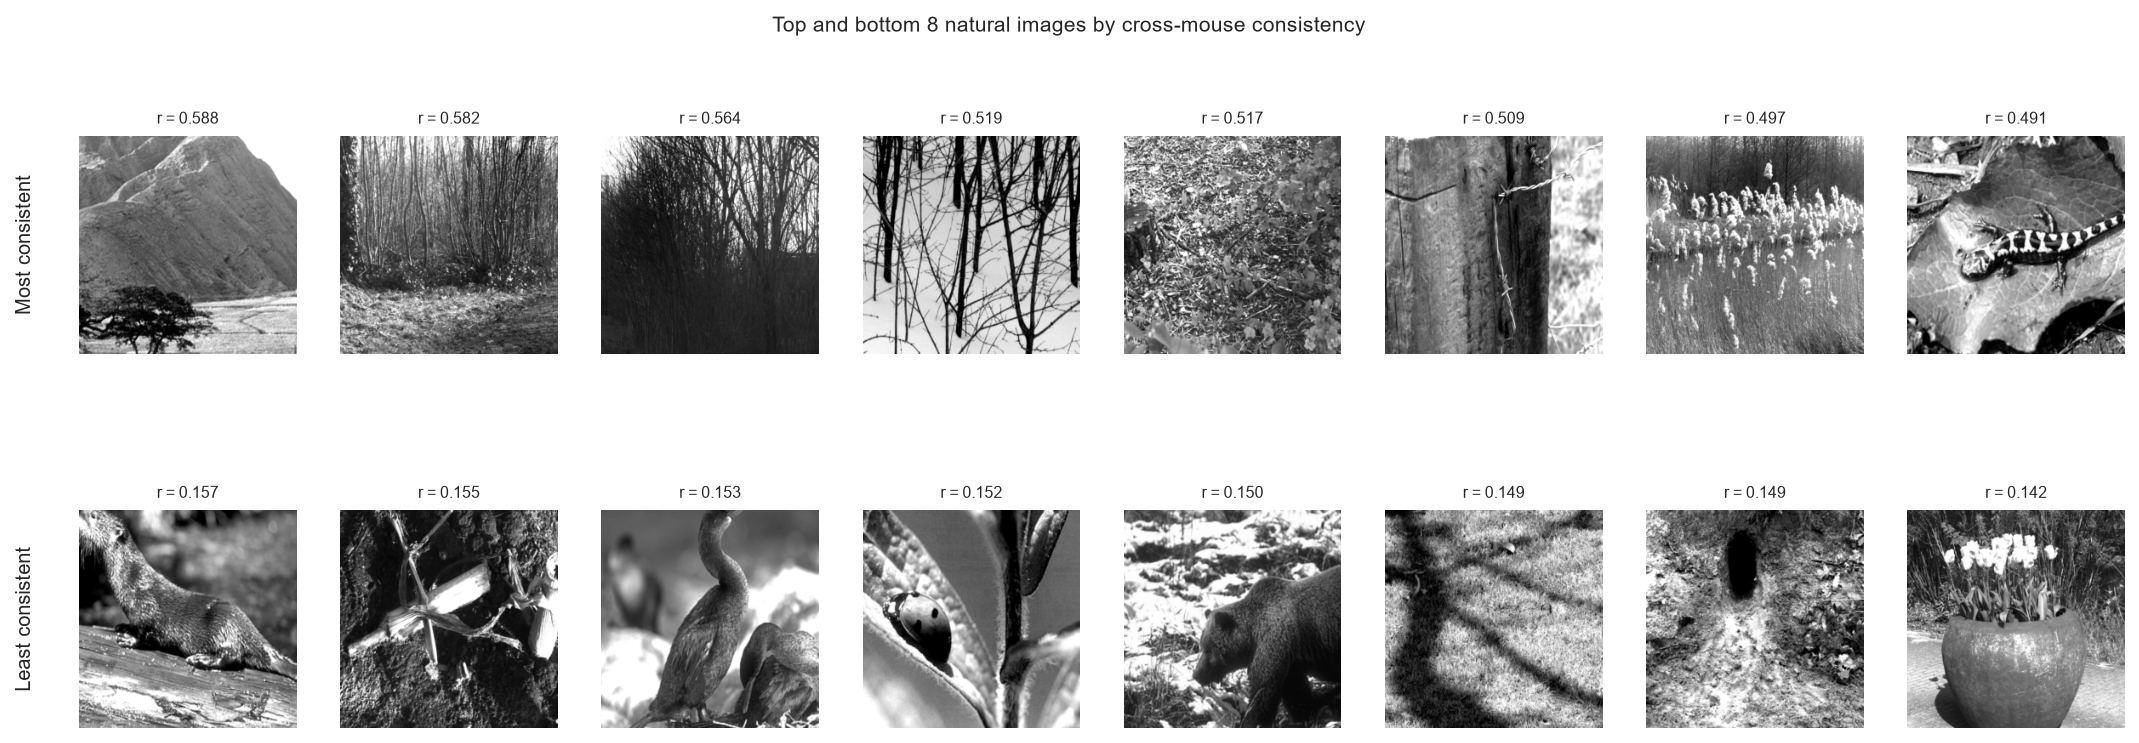

In [11]:
fig, axes = plt.subplots(2, N_GALLERY, figsize=(2.2 * N_GALLERY, 5.4),
                         gridspec_kw={'hspace': 0.5})

gallery_labels        = []
gallery_image_ids     = []
gallery_consistencies = []

for row, (ids, label) in enumerate([(top_ids, 'Most consistent'),
                                     (bot_ids, 'Least consistent')]):
    for col, img_id in enumerate(ids):
        axes[row, col].imshow(natural_scenes[img_id], cmap='gray',
                              vmin=0, vmax=255)
        axes[row, col].set_title(f'r = {consistency[img_id]:.3f}', fontsize=7.5)
        axes[row, col].axis('off')
    axes[row, 0].text(-0.25, 0.5, label, fontsize=9.5, rotation=90,
                      va='center', ha='center', transform=axes[row, 0].transAxes)
    gallery_labels.extend([label] * len(ids))
    gallery_image_ids.extend(list(ids))
    gallery_consistencies.extend([consistency[img_id] for img_id in ids])

fig.suptitle(f'Top and bottom {N_GALLERY} natural images by cross-mouse consistency\n',
             fontsize=10, y=1.01)

print_figure_data(
    'Fig S1 — gallery of high- and low-consistency natural images',
    panel_label=gallery_labels,
    image_id=np.array(gallery_image_ids),
    consistency=np.array(gallery_consistencies),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figS1_image_gallery.png', bbox_inches='tight')
plt.show()